# Linear Regression of California Housing

## Package Breakdown:

| Library      | Purpose                                                        |
|--------------|-----------------------------------------------------------------|
| numpy        | Numerical computations and array operations                     |
| pandas       | Data loading, manipulation, and preprocessing                   |
| scikit-learn | Machine learning models and preprocessing tools                 |
| matplotlib   | Data visualization and plotting                                 |
| seaborn      | Statistical data visualization (optional but recommended)       |

## Key Scikit-Learn Modules:

- `train_test_split()` - Split data into training/testing sets
- `LinearRegression()` - Linear regression model
- `StandardScaler()` - Feature scaling/normalization
- `mean_squared_error()`, `r2_score()`, `mean_absolute_error()` - Model evaluation metrics

## Preprocessing

### Installing Packages

In [58]:
%pip install numpy pandas scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


### Importing Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

### Load/Reading the data

In [60]:
df = pd.read_csv('datasets/california-housing/housing.csv')

### Exploring the dataset

In [61]:
# Display first few rows
print("First few rows of the dataset:")
print(df.head())

# Dataset shape
print(f"\nDataset shape: {df.shape}")

# Data types
print("\nData types:")
print(df.dtypes)

# Missing values
print("\nMissing values:")
print(df.isnull().sum())

# Statistical summary
print("\nStatistical summary:")
print(df.describe())

First few rows of the dataset:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  

Dataset shape: (20640, 10)

Data types:
lon

### Data Preprocessing

In [62]:
# Check for missing values and handle them
df = df.dropna()  # Remove rows with missing values

# Display dataset info after cleaning
print(f"Dataset shape after cleaning: {df.shape}")

Dataset shape after cleaning: (20433, 10)


### Splitting Data

In [63]:
# Separate features (X) and target variable (y)
X = df.drop('median_house_value', axis=1)  # Features (all columns except target)
y = df['median_house_value']  # Target variable

# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (16346, 9)
Testing set size: (4087, 9)


### Feature Scaling

In [64]:
# Remove non-numeric columns before scaling because we want only continous features and not categorical
X_train_num = X_train.drop('ocean_proximity', axis=1)
X_test_num = X_test.drop('ocean_proximity', axis=1)

# Create a MinMaxScaler object (scales features to [0, 1] range)
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

# Fit and transform the training data
X_train_scaled = scaler.fit_transform(X_train_num)

# Transform the testing data using the same scaler
X_test_scaled = scaler.transform(X_test_num)

print(f"Feature scaling completed!\n\nScaled Features Statistics:\n\n{X_test_num.describe()} ")

Feature scaling completed!

Scaled Features Statistics:

         longitude     latitude  housing_median_age   total_rooms  \
count  4087.000000  4087.000000         4087.000000   4087.000000   
mean   -119.531395    35.603834           28.705407   2677.342305   
std       1.994034     2.137024           12.651445   2308.508567   
min    -124.210000    32.560000            1.000000     16.000000   
25%    -121.660000    33.930000           18.000000   1450.500000   
50%    -118.470000    34.250000           29.000000   2131.000000   
75%    -118.010000    37.710000           37.000000   3192.000000   
max    -114.310000    41.860000           52.000000  37937.000000   

       total_bedrooms    population   households  median_income  
count     4087.000000   4087.000000  4087.000000    4087.000000  
mean       545.120871   1442.372645   506.712503       3.873020  
std        436.667283   1148.380197   399.005667       1.905377  
min          3.000000      5.000000     3.000000       0.

### Training the model

In [65]:
# Create a Linear Regression model
model = LinearRegression()

# Train the model on scaled training data
model.fit(X_train_scaled, y_train)

print("Model trained successfully")

Model trained successfully


### Predicitons

In [66]:
# Make predictions on training data
y_train_pred = model.predict(X_train_scaled)

# Make predictions on testing data
y_test_pred = model.predict(X_test_scaled)

print("Predictions made successfully")

Predictions made successfully


### Evaluating the model

In [67]:
# Calculate evaluation metrics for training data
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Calculate evaluation metrics for testing data
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

# Print results
print("Training Metrics:")
print(f"MSE: {train_mse:.4f}")
print(f"RMSE: {train_rmse:.4f}")
print(f"MAE: {train_mae:.4f}")
print(f"R² Score: {train_r2:.4f}")

print("\nTesting Metrics:")
print(f"MSE: {test_mse:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"MAE: {test_mae:.4f}")
print(f"R² Score: {test_r2:.4f}")

Training Metrics:
MSE: 4817977906.7658
RMSE: 69411.6554
MAE: 50629.4974
R² Score: 0.6360

Testing Metrics:
MSE: 4921881237.6281
RMSE: 70156.1205
MAE: 51372.6722
R² Score: 0.6401

MSE: 4817977906.7658
RMSE: 69411.6554
MAE: 50629.4974
R² Score: 0.6360

Testing Metrics:
MSE: 4921881237.6281
RMSE: 70156.1205
MAE: 51372.6722
R² Score: 0.6401


### Visualization

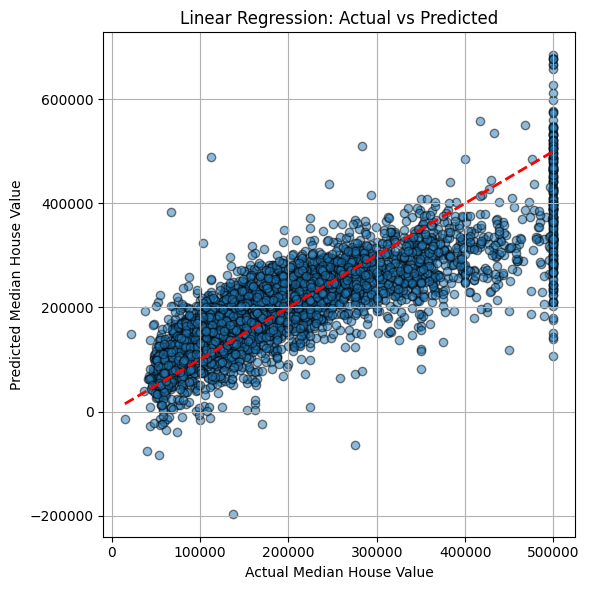

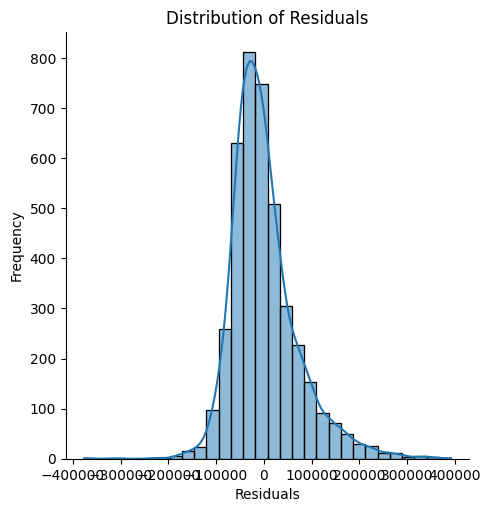

In [70]:
# Actual vs Predicted
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred, alpha=0.5, edgecolor="k")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", linewidth=2)
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Linear Regression: Actual vs Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

# Residual distribution
sns.displot(y_test - y_test_pred, bins=30, kde=True)
plt.title("Distribution of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

### Model Interpretation

In [69]:
# Print model coefficients
print("Model Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef:.6f}")

# Print intercept
print(f"\nIntercept: {model.intercept_:.6f}")

# Model equation
print("\nLinear Regression Equation:")
print(f"median_house_value = {model.intercept_:.4f} + ", end="")
terms = [f"{coef:.6f} × {feature}" for feature, coef in zip(X.columns, model.coef_)]
print(" + ".join(terms))

Model Coefficients:
longitude: -420361.455336
latitude: -398382.164508
housing_median_age: 58909.952532
total_rooms: -331860.373620
total_bedrooms: 746410.938358
population: -1311516.057383
households: 253215.481556
median_income: 584260.595573

Intercept: 364721.546964

Linear Regression Equation:
median_house_value = 364721.5470 + -420361.455336 × longitude + -398382.164508 × latitude + 58909.952532 × housing_median_age + -331860.373620 × total_rooms + 746410.938358 × total_bedrooms + -1311516.057383 × population + 253215.481556 × households + 584260.595573 × median_income
